In [6]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [7]:
base_dir = '/content/drive/MyDrive/Colab Notebooks/Meissasoft/Task_2/Plants_Mood_Classification'
train_dir = base_dir + '/Train_Data'
test_dir = base_dir + '/Test_Data'

In [8]:
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator

In [9]:
#image preprocessing
train_data=ImageDataGenerator(
    rescale=1./255,
    zoom_range=0.2,
    horizontal_flip=True,
    rotation_range=20,
    width_shift_range=0.2,
    height_shift_range=0.2,
    shear_range=0.1,
    fill_mode='nearest'
)


test_data = ImageDataGenerator(rescale=1./255)

In [25]:
# iterators
train_generator = train_data.flow_from_directory(
    train_dir,
    target_size=(128, 128),
    batch_size=32,
    class_mode='categorical'
)

test_generator = test_data.flow_from_directory(
    test_dir,
    target_size=(128, 128),
    batch_size=32,
    class_mode='categorical'
)

Found 6800 images belonging to 4 classes.
Found 546 images belonging to 4 classes.


In [26]:
import numpy as np
print(test_generator.class_indices)      # Class names
print(np.bincount(test_generator.classes))  # Count per class

{'Happy': 0, 'Overwatered': 1, 'Stressed': 2, 'Thirsty': 3}
[127 187 161  71]


In [27]:
from tensorflow import keras

In [28]:
def modelCNN():
  model=keras.Sequential([
      #input layer
      keras.layers.Input(shape=(128,128,3)),
      #convolutional layer 1
      keras.layers.Conv2D(filters=32,kernel_size=(3,3),activation='relu'),
      keras.layers.MaxPooling2D(pool_size=(2,2)),
      #convolutional layer 2
      keras.layers.Conv2D(filters=64,kernel_size=(3,3),activation='relu'),
      keras.layers.MaxPooling2D(pool_size=(2,2)),
      #convlutional layer 3
      keras.layers.Conv2D(filters=128,kernel_size=(3,3),activation='relu'),
      keras.layers.MaxPooling2D(pool_size=(2,2)),
      #flatten layer
      keras.layers.Flatten(),
      #hidden layer
      keras.layers.Dense(128,activation='relu'),
      #dropout
      keras.layers.Dropout(0.5),
      #output layer
      keras.layers.Dense(4,activation='softmax')
                          ])
  return model

In [29]:
model=modelCNN()
model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_3 (Conv2D)               │ (None, 126, 126, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 63, 63, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 61, 61, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 30, 30, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 28, 28, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ (None, 14, 14, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 25088)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 128)            │     3,211,392 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 4)              │           516 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,305,156 (12.61 MB)

 Trainable params: 3,305,156 (12.61 MB)

 Non-trainable params: 0 (0.00 B)

In [30]:
model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])

history = model.fit(train_generator, epochs=20, validation_data=test_generator)

/usr/local/lib/python3.11/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/20
213/213 ━━━━━━━━━━━━━━━━━━━━ 80s 364ms/step - accuracy: 0.5017 - loss: 1.0600 - val_accuracy: 0.8333 - val_loss: 0.4465
Epoch 2/20
213/213 ━━━━━━━━━━━━━━━━━━━━ 78s 364ms/step - accuracy: 0.8188 - loss: 0.4739 - val_accuracy: 0.9377 - val_loss: 0.1876
Epoch 3/20
213/213 ━━━━━━━━━━━━━━━━━━━━ 78s 366ms/step - accuracy: 0.8722 - loss: 0.3455 - val_accuracy: 0.8516 - val_loss: 0.4402
Epoch 4/20
213/213 ━━━━━━━━━━━━━━━━━━━━ 76s 357ms/step - accuracy: 0.8921 - loss: 0.2947 - val_accuracy: 0.8755 - val_loss: 0.3240
Epoch 5/20
213/213 ━━━━━━━━━━━━━━━━━━━━ 77s 361ms/step - accuracy: 0.9175 - loss: 0.2337 - val_accuracy: 0.9176 - val_loss: 0.2895
Epoch 6/20
213/213 ━━━━━━━━━━━━━━━━━━━━ 82s 364ms/step - accuracy: 0.9184 - loss: 0.2313 - val_accuracy: 0.9011 - val_loss: 0.2118
Epoch 7/20
213/213 ━━━━━━━━━━━━━━━━━━━━ 78s 364ms/step - accuracy: 0.9337 - loss: 0.1897 - val_accuracy: 0.7967 - val_loss: 0.7343
Epoch 8/20
213/213 ━━━━━━━━━━━━━━━━━━━━ 76s 358ms/step - accuracy: 0.9297 - loss: 0

In [31]:
# Evaluation
loss, accuracy = model.evaluate(test_generator)
print(f'Accuracy: {accuracy * 100:.2f}%')

18/18 ━━━━━━━━━━━━━━━━━━━━ 2s 102ms/step - accuracy: 0.9773 - loss: 0.0726
Accuracy: 97.44%


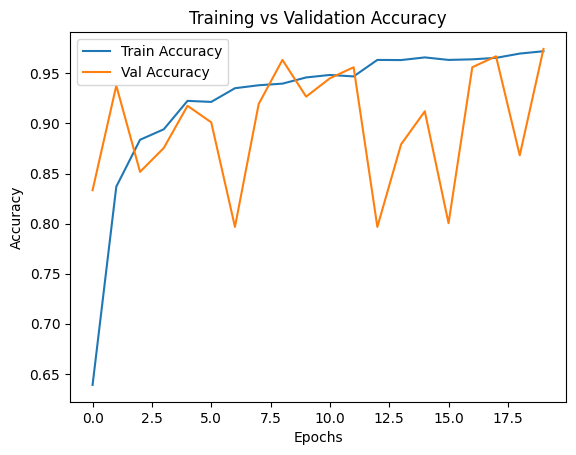

In [32]:
import matplotlib.pyplot as plt

plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Val Accuracy')
plt.legend()
plt.xlabel("Epochs")
plt.ylabel("Accuracy")
plt.title("Training vs Validation Accuracy")
plt.show()

In [33]:
from sklearn.metrics import classification_report
import numpy as np

y_true = test_generator.classes
y_pred_probs = model.predict(test_generator)
y_pred = np.argmax(y_pred_probs, axis=1)
class_labels = list(test_generator.class_indices.keys())

report = classification_report(y_true, y_pred, target_names=class_labels, output_dict=True)

for class_name in class_labels:
    print(f"Class: {class_name}")
    print(f"  Precision: {report[class_name]['precision']:.2f}")
    print(f"  Recall:    {report[class_name]['recall']:.2f}")
    print(f"  F1-score:  {report[class_name]['f1-score']:.2f}")
    print(f"  Support:   {report[class_name]['support']}\n")

print(f"Overall Accuracy: {report['accuracy']*100:.2f}%")


18/18 ━━━━━━━━━━━━━━━━━━━━ 2s 117ms/step
Class: Happy
  Precision: 0.20
  Recall:    0.20
  F1-score:  0.20
  Support:   127.0

Class: Overwatered
  Precision: 0.32
  Recall:    0.32
  F1-score:  0.32
  Support:   187.0

Class: Stressed
  Precision: 0.30
  Recall:    0.28
  F1-score:  0.29
  Support:   161.0

Class: Thirsty
  Precision: 0.14
  Recall:    0.15
  F1-score:  0.15
  Support:   71.0

Overall Accuracy: 25.82%
